# 实验零：开发板介绍与使用教程

**YOLO 端侧部署与 TBE 自定义后处理集成 | Atlas 200I DK A2 + Ascend 310/310B + CANN + PyACL**

本章面向第一次接触 Atlas 200I DK A2 开发者套件的学生，目标不是直接运行 YOLO，而是先把开发板用起来：认识接口、制作系统启动卡、正确接线、上电启动、登录系统、打开 Jupyter Lab，并确认 CANN、PyACL 与 NPU 设备处于可用状态。

完成本章后，学生应能够独立完成开发板从“空板/新卡”到“可运行端侧推理实验环境”的准备工作。

## 学习目标

1. 能够说明 Atlas 200I DK A2 开发者套件的主要硬件接口及其在端侧 AI 实验中的用途。
2. 能够使用 Ascend 一键制卡工具制作 Micro SD 系统启动卡，并理解在线制卡、本地制卡和网络配置的区别。
3. 能够按正确顺序完成插卡、拨码、接线、上电、SSH 登录和 Jupyter Lab 访问。
4. 能够通过基础命令检查 CANN、PyACL、ATC、msprof 和 NPU 设备状态，为后续 YOLO OM 模型推理实验做准备。


## 实验卡片

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">项目</th>
      <th style="text-align: left;">内容</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">知识域</td>
      <td style="text-align: left;">端侧高性能推理与算子开发</td>
    </tr>
    <tr>
      <td style="text-align: left;">实验名称</td>
      <td style="text-align: left;">YOLO 端侧部署与 TBE 自定义后处理集成</td>
    </tr>
    <tr>
      <td style="text-align: left;">本章名称</td>
      <td style="text-align: left;">开发板介绍与使用教程</td>
    </tr>
    <tr>
      <td style="text-align: left;">目标硬件</td>
      <td style="text-align: left;">Atlas 200I DK A2 开发者套件</td>
    </tr>
    <tr>
      <td style="text-align: left;">核心软件</td>
      <td style="text-align: left;">Ascend 一键制卡工具、开发板系统镜像、CANN、PyACL、Jupyter Lab</td>
    </tr>
    <tr>
      <td style="text-align: left;">后续承接</td>
      <td style="text-align: left;">OM 模型转换、PyACL 推理、CPU/NPU 后处理对比、自定义算子、MindStudio Profiling</td>
    </tr>
  </tbody>
</table>


## 1. 开发板在本实验中的角色

Atlas 200I DK A2 可以理解为一台面向边缘 AI 应用的小型 Linux 设备。它集成 Ascend AI 处理器、CPU、内存、网络接口、显示接口、USB 接口、摄像头接口和扩展接口，能够在端侧直接运行推理程序。

在本实验中，开发板承担以下任务：

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">任务</th>
      <th style="text-align: left;">说明</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">运行操作系统</td>
      <td style="text-align: left;">通过 Micro SD 卡启动 Ubuntu 或 openEuler 系统，提供 shell、Python、Jupyter Lab 等开发环境</td>
    </tr>
    <tr>
      <td style="text-align: left;">执行 NPU 推理</td>
      <td style="text-align: left;">加载 ATC 转换后的 YOLO OM 模型，在 Ascend 计算单元上完成前向推理</td>
    </tr>
    <tr>
      <td style="text-align: left;">接入输入源</td>
      <td style="text-align: left;">读取图片、视频文件，或连接 USB / MIPI 摄像头获取实时画面</td>
    </tr>
    <tr>
      <td style="text-align: left;">输出检测结果</td>
      <td style="text-align: left;">输出检测框、类别、置信度，可保存图片、视频或在显示端展示</td>
    </tr>
    <tr>
      <td style="text-align: left;">承载后处理优化</td>
      <td style="text-align: left;">先在 CPU 上执行 YOLO decode、阈值过滤、NMS，再将热点后处理迁移到 NPU 自定义算子</td>
    </tr>
    <tr>
      <td style="text-align: left;">采集性能数据</td>
      <td style="text-align: left;">使用 msprof / MindStudio Profiling 分析模型推理、数据搬运、后处理算子的耗时</td>
    </tr>
  </tbody>
</table>

如果开发板无法稳定登录、NPU 不可见或 CANN 环境变量不正确，后续 OM 推理和自定义算子都无法顺利进行。


## 2. 实物观察与接口标注

请学生先对照自己的开发板实物以及说明文档，找到下表中的接口。

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">接口 / 部件</th>
      <th style="text-align: left;">主要作用</th>
      <th style="text-align: left;">本实验是否常用</th>
      <th style="text-align: left;">使用提醒</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">千兆以太网口 x2</td>
      <td style="text-align: left;">网络登录、文件传输、联网下载依赖</td>
      <td style="text-align: left;">常用</td>
      <td style="text-align: left;">通常 eth1 用于静态直连，eth0 可用于 DHCP 联网，具体以制卡配置为准</td>
    </tr>
    <tr>
      <td style="text-align: left;">USB 3.0 Type-A x2</td>
      <td style="text-align: left;">连接 U 盘、USB 摄像头、键盘、鼠标、USB 拓展坞</td>
      <td style="text-align: left;">常用</td>
      <td style="text-align: left;">摄像头实验优先使用 USB 摄像头时要确认设备名，如 <code>/dev/video0</code></td>
    </tr>
    <tr>
      <td style="text-align: left;">USB 3.0 Type-C</td>
      <td style="text-align: left;">调试连接、USB 虚拟网卡直连</td>
      <td style="text-align: left;">常用</td>
      <td style="text-align: left;">适合 PC 与开发板直连；Windows 侧可能需要识别 RNDIS/USB Ethernet 网卡</td>
    </tr>
    <tr>
      <td style="text-align: left;">HDMI 接口 x2</td>
      <td style="text-align: left;">连接显示器或输出画面</td>
      <td style="text-align: left;">可选</td>
      <td style="text-align: left;">HDMI0 通常用于图形桌面显示；HDMI1 在部分版本中为预留或特定输出场景，不建议作为课堂主路径</td>
    </tr>
    <tr>
      <td style="text-align: left;">电源接口</td>
      <td style="text-align: left;">为开发板供电</td>
      <td style="text-align: left;">必需</td>
      <td style="text-align: left;">使用套件匹配电源，避免供电不足导致系统重启或 NPU 异常</td>
    </tr>
    <tr>
      <td style="text-align: left;">开关机按键</td>
      <td style="text-align: left;">开机、关机</td>
      <td style="text-align: left;">必需</td>
      <td style="text-align: left;">短按可触发开关机；长时间不用应正常关机后断电</td>
    </tr>
    <tr>
      <td style="text-align: left;">复位按键</td>
      <td style="text-align: left;">触发系统复位</td>
      <td style="text-align: left;">排错时使用</td>
      <td style="text-align: left;">程序卡死时可作为最后手段，正常实验优先使用系统命令关机/重启</td>
    </tr>
    <tr>
      <td style="text-align: left;">U 盘制卡按键</td>
      <td style="text-align: left;">硬件预留的制卡相关按键</td>
      <td style="text-align: left;">不使用</td>
      <td style="text-align: left;">官方文档说明该按键当前暂不可用，制卡应使用 PC 端 Ascend 一键制卡工具</td>
    </tr>
    <tr>
      <td style="text-align: left;">拨码开关</td>
      <td style="text-align: left;">选择启动介质</td>
      <td style="text-align: left;">必需</td>
      <td style="text-align: left;">当前课堂使用 SD 卡启动，拨码需按 SD 启动方式设置</td>
    </tr>
    <tr>
      <td style="text-align: left;">Micro SD 卡接口</td>
      <td style="text-align: left;">插入系统启动卡</td>
      <td style="text-align: left;">必需</td>
      <td style="text-align: left;">制卡完成后插入；插拔前必须断电，Windows 弹出“是否格式化”时选择取消</td>
    </tr>
    <tr>
      <td style="text-align: left;">M.2 Key M 连接器</td>
      <td style="text-align: left;">扩展 NVMe SSD 存储</td>
      <td style="text-align: left;">可选</td>
      <td style="text-align: left;">数据集、模型较大时可扩展存储；本实验基础流程不强制使用</td>
    </tr>
    <tr>
      <td style="text-align: left;">M.2 Key E 连接器</td>
      <td style="text-align: left;">扩展无线通信模块等</td>
      <td style="text-align: left;">可选</td>
      <td style="text-align: left;">是否可用取决于具体模块和驱动，课堂基础流程不依赖该接口</td>
    </tr>
    <tr>
      <td style="text-align: left;">MIPI-CSI 51Pin x2</td>
      <td style="text-align: left;">连接 MIPI 摄像头模组</td>
      <td style="text-align: left;">可选</td>
      <td style="text-align: left;">用于摄像头端侧推理，连接前确认排线方向和断电操作</td>
    </tr>
    <tr>
      <td style="text-align: left;">MIPI-DSI 51Pin</td>
      <td style="text-align: left;">连接显示屏模组</td>
      <td style="text-align: left;">可选</td>
      <td style="text-align: left;">用于显示扩展场景，本实验主要使用浏览器或保存图片查看结果</td>
    </tr>
    <tr>
      <td style="text-align: left;">40Pin 扩展接口</td>
      <td style="text-align: left;">连接传感器、小车、机械臂等外设</td>
      <td style="text-align: left;">可选</td>
      <td style="text-align: left;">涉及 GPIO/I2C/SPI/UART 等，接线前必须确认电平和引脚定义</td>
    </tr>
    <tr>
      <td style="text-align: left;">风扇接口</td>
      <td style="text-align: left;">连接散热风扇</td>
      <td style="text-align: left;">推荐</td>
      <td style="text-align: left;">长时间推理或 Profiling 时建议保持良好散热</td>
    </tr>
    <tr>
      <td style="text-align: left;">LED 指示灯</td>
      <td style="text-align: left;">显示电源、运行、网络等状态</td>
      <td style="text-align: left;">常用</td>
      <td style="text-align: left;">上电后可通过指示灯判断是否启动稳定</td>
    </tr>
    <tr>
      <td style="text-align: left;">纽扣电池</td>
      <td style="text-align: left;">断电后为计时供电</td>
      <td style="text-align: left;">不操作</td>
      <td style="text-align: left;">学生一般不需要拆装</td>
    </tr>
    <tr>
      <td style="text-align: left;">Atlas 200I A2 加速模块连接器</td>
      <td style="text-align: left;">连接核心加速模块与底板</td>
      <td style="text-align: left;">不操作</td>
      <td style="text-align: left;">不作为实验接口使用，不建议拆卸</td>
    </tr>
  </tbody>
</table>


## 3. 最小可用接线方案

为了降低课堂排错复杂度，首次实验建议使用最小接线方案。等开发板能稳定登录后，再接摄像头、显示器或其他外设。

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">场景</th>
      <th style="text-align: left;">需要连接的线缆</th>
      <th style="text-align: left;">适用说明</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">推荐方案：RJ45 静态直连</td>
      <td style="text-align: left;">电源线 + Micro SD 卡 + 网线连接 PC 与 eth1</td>
      <td style="text-align: left;">适合课堂统一 IP，便于 SSH、Jupyter Lab、scp 文件传输</td>
    </tr>
    <tr>
      <td style="text-align: left;">调试方案：Type-C 直连</td>
      <td style="text-align: left;">电源线 + Micro SD 卡 + Type-C 线连接 PC</td>
      <td style="text-align: left;">适合无网线场景，依赖 PC 正确识别 USB 虚拟网卡</td>
    </tr>
    <tr>
      <td style="text-align: left;">本机显示方案</td>
      <td style="text-align: left;">电源线 + Micro SD 卡 + HDMI0 + USB 键鼠</td>
      <td style="text-align: left;">适合无法 SSH 登录时排查系统启动状态</td>
    </tr>
    <tr>
      <td style="text-align: left;">联网下载方案</td>
      <td style="text-align: left;">电源线 + Micro SD 卡 + eth0 接路由器/交换机</td>
      <td style="text-align: left;">适合开发板需要联网下载包，通常由 DHCP 分配 IP</td>
    </tr>
  </tbody>
</table>


## 4. 使用 Ascend 一键制卡工具制作系统卡

开发板系统通常从 Micro SD 卡启动。制卡就是把官方系统镜像烧录到 Micro SD 卡中，使开发板上电后能够进入预装好基础组件的 Linux 环境。

这里使用 Windows 版 Ascend 一键制卡工具完成。

### 4.1 制卡前准备

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">准备项</th>
      <th style="text-align: left;">要求</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">Windows PC</td>
      <td style="text-align: left;">用于安装和运行 Ascend 一键制卡工具</td>
    </tr>
    <tr>
      <td style="text-align: left;">Micro SD 卡</td>
      <td style="text-align: left;">推荐 64GB 或更大容量；制卡会格式化整张卡，旧数据必须提前备份</td>
    </tr>
    <tr>
      <td style="text-align: left;">读卡器</td>
      <td style="text-align: left;">将 Micro SD 卡接入 PC</td>
    </tr>
    <tr>
      <td style="text-align: left;">稳定网络</td>
      <td style="text-align: left;">在线制卡需要持续下载镜像，建议网络稳定且不要让 PC 休眠</td>
    </tr>
    <tr>
      <td style="text-align: left;">开发板套件</td>
      <td style="text-align: left;">制卡时先不要插入开发板，上电前再插卡</td>
    </tr>
  </tbody>
</table>

### 4.2 下载并安装制卡工具

1. 打开昇腾社区 Atlas 200I DK A2 资源页或快速开始文档，下载 Windows 版制卡工具：`Ascend-devkit-imager_latest_win-x86_64.exe`。链接如下：https://www.hiascend.com/document/detail/zh/Atlas200IDKA2DeveloperKit/latest/qs/qs_0005.html
2. 浏览器或 Windows 可能提示该安装包来自网络。确认来源为官方昇腾社区后，按照文档提示选择“保留”、“显示详细信息”、“仍然保留”。
3. 双击安装包。如果 Windows 弹出“Windows 已保护你的电脑”，选择“更多信息”后点击“仍要运行”。
4. 用户账户控制弹窗中选择“是”，按默认安装向导完成安装。
5. 安装完成后打开 **Ascend 一键制卡工具**。

### 4.3 选择制卡方式

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">制卡方式</th>
      <th style="text-align: left;">适用情况</th>
      <th style="text-align: left;">操作要点</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">在线制卡，推荐</td>
      <td style="text-align: left;">PC 可以稳定联网，不想提前下载镜像</td>
      <td style="text-align: left;">工具自动获取 Ubuntu 22.04 或 openEuler 22.03 镜像列表，选择推荐或最新版本后烧录</td>
    </tr>
    <tr>
      <td style="text-align: left;">本地制卡</td>
      <td style="text-align: left;">课堂网络不稳定，或教师已经提前下载镜像</td>
      <td style="text-align: left;">先将镜像文件下载到 PC，在工具中选择“本地制卡”，再选择镜像文件烧录</td>
    </tr>
  </tbody>
</table>

如果是教学机房，推荐教师提前完成一次本地镜像下载，并将镜像文件放到局域网共享目录。学生制卡时使用本地制卡，可以避免多人同时在线下载导致失败。



### 4.4 网络参数配置

制卡工具支持提前写入开发板网络配置。没有特殊网络规划时，建议保持默认配置：

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">接口</th>
      <th style="text-align: left;">默认用途</th>
      <th style="text-align: left;">默认配置</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">eth1</td>
      <td style="text-align: left;">PC 与开发板静态直连</td>
      <td style="text-align: left;"><code>192.168.137.100</code></td>
    </tr>
    <tr>
      <td style="text-align: left;">eth0</td>
      <td style="text-align: left;">接路由器或交换机联网</td>
      <td style="text-align: left;">DHCP 动态获取 IP</td>
    </tr>
    <tr>
      <td style="text-align: left;">Type-C</td>
      <td style="text-align: left;">USB 虚拟网卡直连</td>
      <td style="text-align: left;"><code>192.168.0.2</code></td>
    </tr>
  </tbody>
</table>

注意：三个接口不要配置在同一个网段。例如 Type-C 使用 `192.168.0.2/24` 时，eth1 不应再设置为 `192.168.0.x/24`。课堂上如果没有明确要求，保持默认配置最稳妥。

### 4.5 烧录镜像

1. 准备一张 32G 以上的 SD 卡以及读卡器，然后把 SD 卡通过读卡器插到电脑的 USB 接口；
4. 如无特殊要求，网络配置保持默认；
5. 选择“在线制卡”方式，点击“烧录镜像”按钮即可实现一键制卡。烧录过程中不要拔卡、不要断电、不要让 PC 休眠。
6. 工具提示“烧录成功”后点击完成。
7. 如果 Windows 弹出“需要格式化磁盘才能使用”的提示，选择“取消”。这是因为 Windows 不能识别 Linux 分区，不能格式化。
8. 安全弹出读卡器，取出 SD 卡。

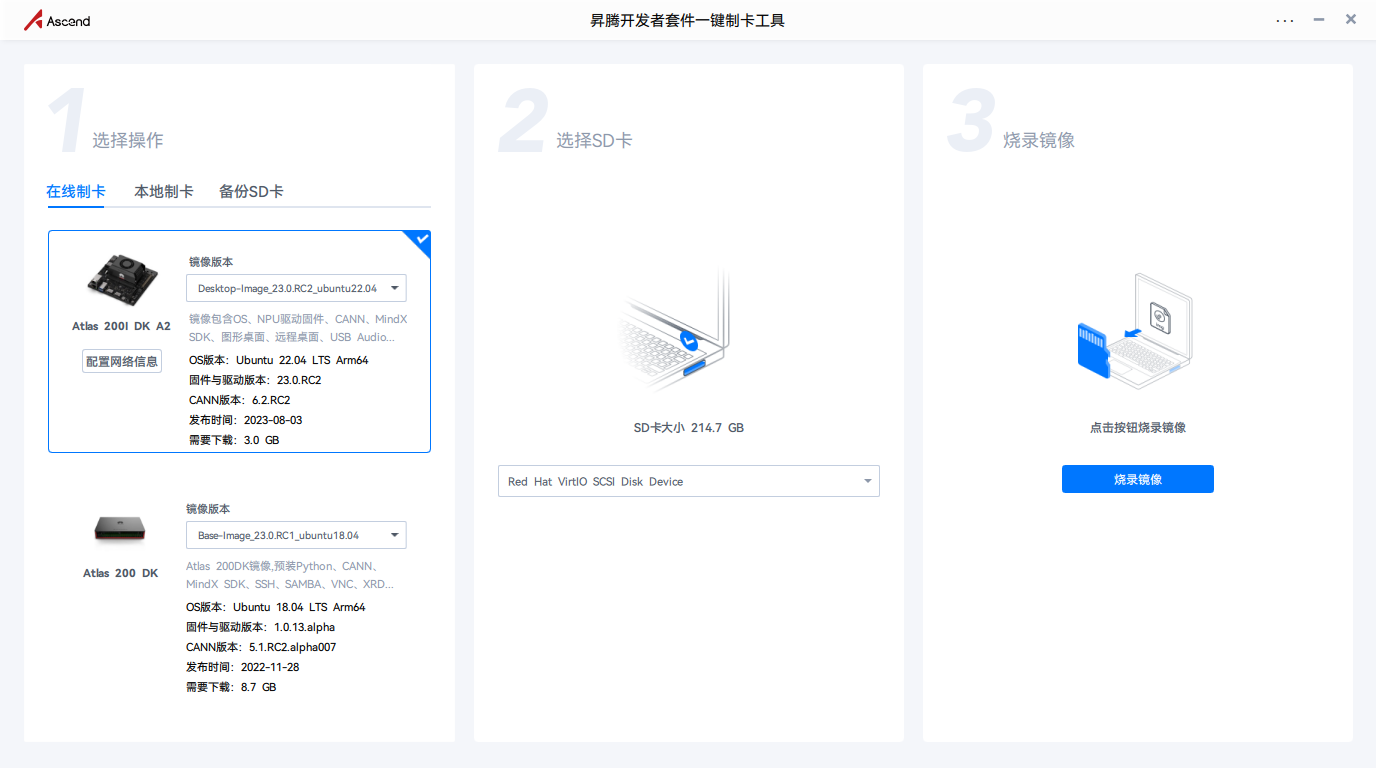

制卡完成后，这张卡就是开发板的系统启动卡。后续插入开发板前，确认开发板处于断电状态。


## 5. 启动开发者套件

制卡完成后，可以通过“本地显示”或者“远程登录”两种方式启动开发板。请大家根据实际情况选择适合自己的方式。

### 5.1 本地显示模式

1. 确认开发板断电。
2. 将 SD 卡插入开发者套件的 SD 插槽，并确保完全推入插槽底部。
3. 设置拨码开关为 SD 卡启动。并检查官方文档中的开关状态。
4. 将显示器、鼠标、键盘接入开发者套件，显示器必须接入开发者套件HDMI接口0。
5. 接入电源适配器。
6. 短按开关机按键（即说明书上的 9 号按键），等待开发板启动。
7. 观察 LED 和网口灯状态。开发者套件上电后，D3、LED1、LED3指示灯会依次绿色常亮，表示启动正常（如下图中白框标识的指示灯）。等待约1分钟即可远程登录若长时间无响应，先断电检查 Micro SD 卡、拨码和供电。

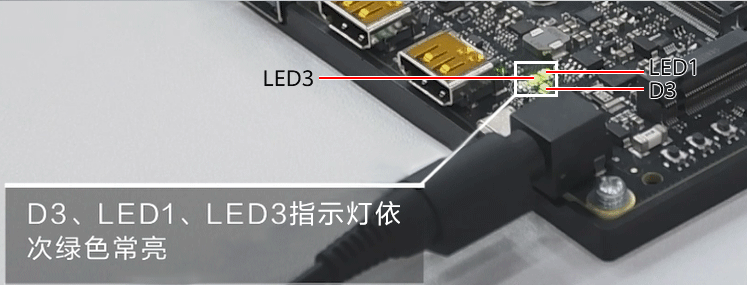

### 5.2 远程登录模式

1. 确认开发板断电。
2. 将 SD 卡插入开发者套件的 SD 插槽，并确保完全推入插槽底部。
3. 设置拨码开关为 SD 卡启动。
4. 有以下两种接线方式：（1）使用 Type-C 线连接开发者套件 Type-C 接口，数据线另一端连接 PC。将电源线插头插入插座，接通开发者套件电源启动开发者套件；
（2）或者使用网线连接开发者套件 以太网口，网线另一端连接 PC，本文后续操作以连接 eth1 网口为例进行操作。将电源线插头插入插座，接通开发者套件电源启动开发者套件。

5. 观察 LED 和网口灯状态。开发者套件上电后，D3、LED1、LED3指示灯会依次绿色常亮，表示启动正常（如下图中白框标识的指示灯）。等待约1分钟即可远程登录若长时间无响应，先断电检查 Micro SD 卡、拨码和供电。

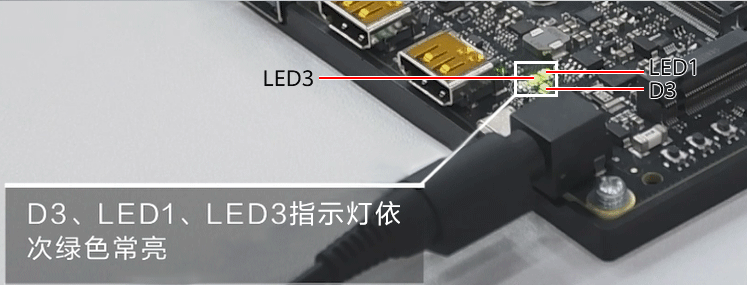

注意事项：

   （1）开发者套件首次上电启动登录后，会进行固件版本检查，若与镜像内驱动版本不符会进行自动升级，1分钟内请勿下电，升级固件（大约1分钟）后系统自动重启（升级固件期间显示器会闪屏显示，重启期间会显示黑屏，直到开发者套件启动运行后显示正常），重启后即可正常登录使用。

   （2）开发者套件上电后请勿插拔SD卡。

   （3）插拔 Micro SD 卡、MIPI 摄像头、40Pin 外设和扩展模块时，应先关机断电。USB 设备虽然支持热插拔，但初学阶段也建议先完成基础启动后再接入，降低排错难度。


In [ ]:
# ====== 1. 生成开发板连接命令 ======
# 这段代码只生成命令，不会主动连接开发板。请根据课堂实际 IP 修改变量。

board_eth1_ip = "192.168.137.100"
board_typec_ip = "192.168.0.2"
user = "HwHiAiUser"

print("RJ45 eth1 静态直连：")
print(f"ssh {user}@{board_eth1_ip}")
print(f"scp src/data/images/bus.jpg {user}@{board_eth1_ip}:~/")
print(f"浏览器打开: http://{board_eth1_ip}:8000/")
print()
print("Type-C 直连：")
print(f"ssh {user}@{board_typec_ip}")
print(f"浏览器打开: http://{board_typec_ip}:8000/")


## 6. 登录开发者套件

### 6.1 本地显示模式

本节介绍当开发者套件通过HDMI连接线直连显示器时，如何登录开发者套件，以Ubuntu 22.04版本镜像方式登录。

1. 完成本机显示模式的连接启动开发者套件，进入显示器中的开发者套件登录界面。
2. 输入HwHiAiUser用户名登录密码（默认为Mind@123）登录开发者套件，进入图形化桌面。

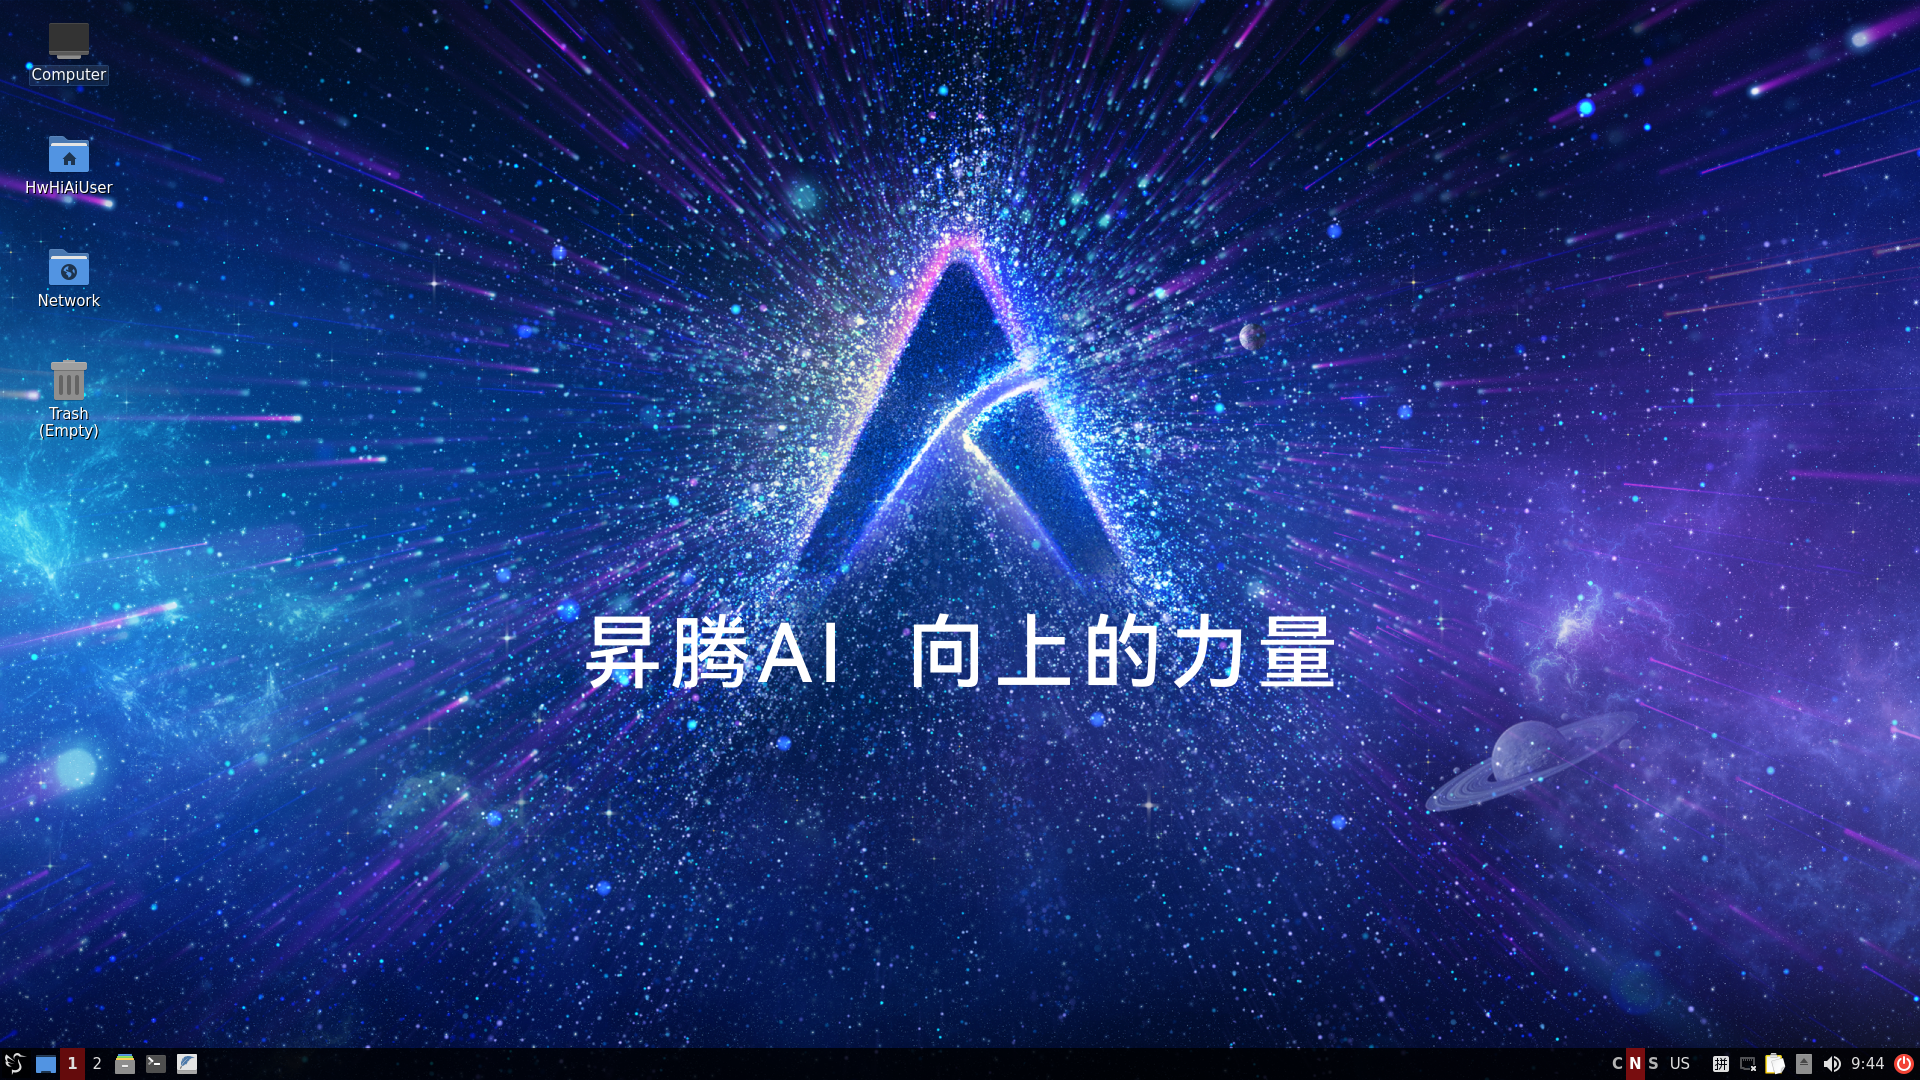

3. 图形化桌面使用方法：

    （1）切换输入法：右键单击右下方工具栏中 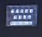 按钮，选择“input method”修改中英文输入法。

    （2）打开浏览器：左键单击左下方工具栏  按钮，选择“Internet >Firefox Web Browser”。

    （3）打开终端：左键单击左下方工具栏  打开终端。

    （4）打开网络：右键单击右下方工具栏  按钮，选择Enable Networking或Enable Wi-Fi。

### 6.2 以太网远程登陆（SSH模式）

本节介绍当开发者套件通过以太网接口和PC连接时，如何在PC将接口IP地址修改为和开发者套件接口IP地址同一个网段（如开发者套件eth1网口为192.168.137.100，PC以太网口为192.168.137.101），并使用SSH工具远程登录开发者套件。Type-C 接口登录方式可参考文档说明，此处不再赘述。

#### 6.2.1 配置PC接口IP地址


1. 单击“设置”按钮，在“网络和Internet”中更改以太网的属性，选择“Internet 协议版本 4（TCP/IPv4）”，单击“属性”。

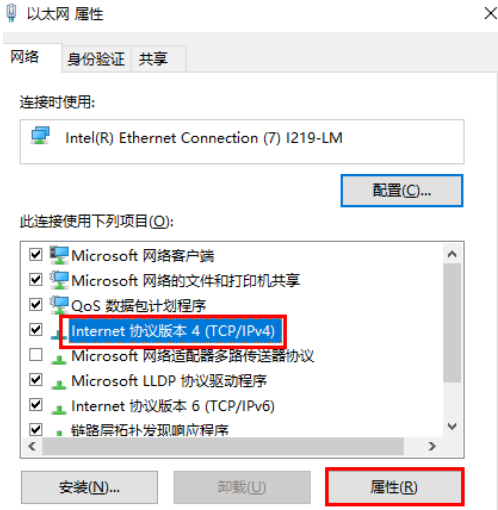

2. 勾选“使用下面的 IP 地址”选项，填写IP地址（图示以192.168.137.101为例）和子网掩码，默认网关与DNS服务器地址为空，单击“确定”保存。

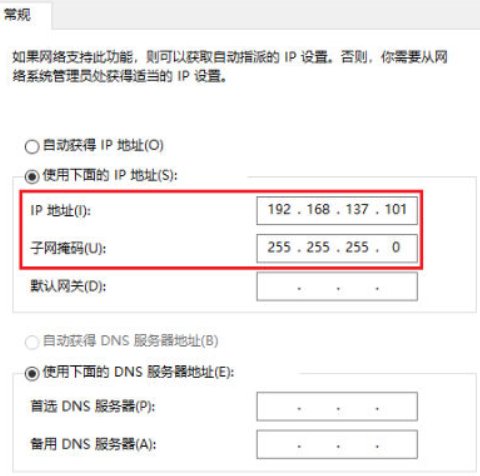

3. 使用快捷键“Win+R”，在运行窗口输入cmd进入命令行窗口。输入 ipconfig 命令查询PC网口IP地址是否修改成功。

#### 6.2.2 远程登录

修改PC接口IP地址后，通过SSH方式登录开发者套件。

1. 下载SSH工具。如 MobaXterm，软件压缩包链接：https://download.mobatek.net/2222022102210348/MobaXterm_Portable_v22.2.zip

2. 解压后获得“MobaXterm_Personal_22.2.exe”启动SSH登录工具，双击启动。

3. 单击左上方的“Session”，然后选择“SSH”进入SSH连接配置界面。根据硬件连接方式填写开发者套件连接PC的接口实际IP地址（制卡中配置的IP地址），勾选“Specify username”选项，填写用户名（以root为例）。图示以192.168.137.100为例，请根据实际修改。

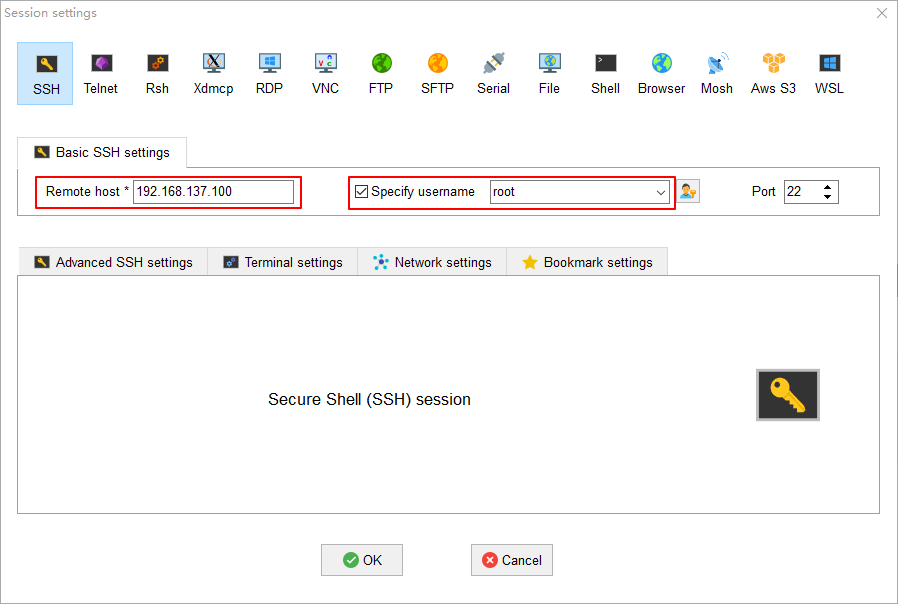

4. 单击“OK”按钮，首次连接开发者套件时，SSH工具提示是否信任连接的设备，单击“Accept”。

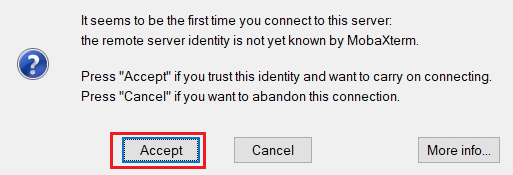

5. 进入远程登录界面后，输入root用户名登录密码（默认为Mind@123）登录开发者套件。

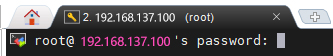

在SSH工具窗口输入密码时，界面不会显示密码和输入位数，输入密码后在键盘按Enter键即可。SSH工具界面会出现保存密码提示，可以单击“No”，不保存密码直接登录开发者套件。

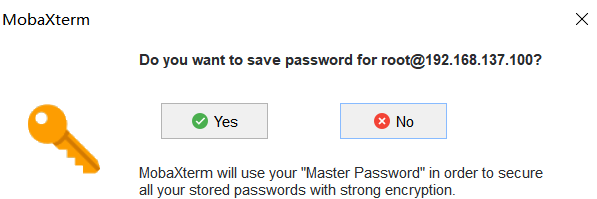

如果单击“Yes”后进入MASTER PASSWORD设置界面，该密码用于找回保存的登录密码，请妥善保管。

6. 检查是否登录成功。烧录的镜像为Ubuntu 22.04时，远程登录开发者套件成功界面如下图所示：

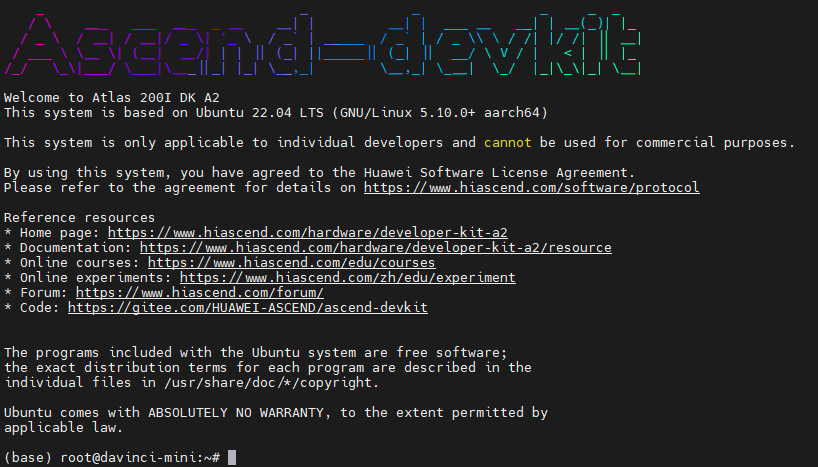


## 7. 登录 Jupyter Lab

### 7.1 本机显示模式

1. 在图形化桌面打开命令终端。

2. 进入“notebooks”目录，在命令终端窗口输入如下命令：
```bash
cd /home/HwHiAiUser/samples/notebooks
```
3. 修改jupyter lab启动脚本（start_notebook.sh）中jupyter lab启动IP地址，执行 `vi start_notebook.sh` 命令修改启动IP地址。在键盘按i键进入编辑模式，将脚本中以下加粗的IP地址修改为127.0.0.1。
```bash
. /usr/local/Ascend/ascend-toolkit/set_env.sh
export PYTHONPATH=/usr/local/Ascend/thirdpart/aarch64/acllite:$PYTHONPATH
if [ $# -eq 1 ];then
    jupyter lab --ip $1 --allow-root --no-browser
else
    jupyter lab --ip 127.0.0.1 --allow-root --no-browser
fi
```
修改完成后，按Esc键退出编辑模式，按键盘输入: `wq` 保存文件。

4. 执行 `./start_notebook.sh` 命令启动jupyter lab。

5. 在回显信息页面按住键盘“Ctrl”键并使用鼠标左键单击回显中加粗的网址链接，进入jupyter lab界面，即可运行开发者套件预置的Python推理样例。


### 7.2 以太网远程登录模式

1. 进入“notebooks”目录，在MobaXterm工具窗口输入如下命令：

```bash
cd /home/HwHiAiUser/samples/notebooks
```

2. jupyter lab启动脚本（start_notebook.sh）中的jupyter lab启动IP地址默认为192.168.137.100，如果烧录镜像时开发者套件以太网口eth1保留了默认IP信息，则跳过本步骤；如果以太网口eth1配置了其他IP地址，则将启动脚本中的IP修改为实际IP地址。
启动IP地址修改方法：执行vi start_notebook.sh命令修改启动IP地址。在键盘按i键进入编辑模式，将脚本中以下加粗的IP地址192.168.137.100修改为实际IP地址。

```bash
. /usr/local/Ascend/ascend-toolkit/set_env.sh
export PYTHONPATH=/usr/local/Ascend/thirdpart/aarch64/acllite:$PYTHONPATH
if [ $# -eq 1 ];then
    jupyter lab --ip $1 --allow-root --no-browser
else
    jupyter lab --ip 192.168.137.100 --allow-root --no-browser
fi
```

3. 执行 `./start_notebook.sh` 命令启动jupyter lab。

4. 在回显信息页面按住键盘“Ctrl”键并使用鼠标左键单击回显中加粗的网址链接，进入jupyter lab界面，即可运行开发者套件预置的Python推理样例。

## 8. CANN、PyACL 与 NPU 环境自检

开发板能登录并不等于 AI 推理环境已经可用。进入 shell 或 Jupyter 后，需要检查以下组件。

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">检查项</th>
      <th style="text-align: left;">命令</th>
      <th style="text-align: left;">判断标准</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">NPU 设备</td>
      <td style="text-align: left;"><code>npu-smi info</code></td>
      <td style="text-align: left;">能看到设备 ID、芯片型号、健康状态、温度、功耗等信息</td>
    </tr>
    <tr>
      <td style="text-align: left;">CANN 环境</td>
      <td style="text-align: left;"><code>echo $ASCEND_HOME_PATH</code></td>
      <td style="text-align: left;">能看到 Ascend Toolkit 路径；如果为空，需要先 source 环境脚本</td>
    </tr>
    <tr>
      <td style="text-align: left;">ATC 工具</td>
      <td style="text-align: left;"><code>atc --version</code></td>
      <td style="text-align: left;">能输出 ATC 版本，后续用于 ONNX 转 OM</td>
    </tr>
    <tr>
      <td style="text-align: left;">PyACL</td>
      <td style="text-align: left;"><code>python3 -c "import acl; print('acl ok')"</code></td>
      <td style="text-align: left;">能导入 <code>acl</code>，后续可用 Python 调用 ACL Runtime</td>
    </tr>
    <tr>
      <td style="text-align: left;">Profiling</td>
      <td style="text-align: left;"><code>msprof --help</code></td>
      <td style="text-align: left;">能输出帮助信息，后续用于性能采集</td>
    </tr>
  </tbody>
</table>

常见环境脚本路径如下，实际路径以镜像为准：

```bash
source /usr/local/Ascend/ascend-toolkit/set_env.sh
```

如果 shell 中命令可用，但 Jupyter 中不可用，说明 Jupyter kernel 启动时没有继承同一套环境变量。解决方法是先在已 source CANN 环境的 shell 中启动 Jupyter，或在 notebook 中手动补充环境变量。


In [ ]:
# ====== 2. 检查当前 Python 依赖 ======
import importlib
import platform
import sys

print("Python:", sys.version)
print("Platform:", platform.platform())

for pkg in ["numpy", "PIL", "yaml", "cv2", "matplotlib"]:
    try:
        module = importlib.import_module(pkg)
        print(f"[OK]   {pkg:12s}", getattr(module, "__version__", "installed"))
    except ImportError:
        print(f"[MISS] {pkg:12s} 请执行 pip install -r requirements.txt")


In [ ]:
# ====== 3. 检查 CANN / PyACL / NPU / Profiling 工具 ======
# 本单元需要在开发板或已经配置昇腾环境的机器上运行。
import os
import shutil
import subprocess


def run_command(cmd, timeout=8, max_chars=1600):
    print(f"\n$ {cmd}")
    try:
        result = subprocess.run(
            cmd,
            shell=True,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            timeout=timeout,
        )
        output = result.stdout.strip()
        print(output[:max_chars] if output else "<no output>")
        if result.returncode != 0:
            print(f"[WARN] return code = {result.returncode}")
    except Exception as exc:
        print(f"[WARN] command failed: {exc}")

print("关键命令位置：")
for name in ["npu-smi", "atc", "msprof", "python3"]:
    print(f"{name:10s}: {shutil.which(name) or 'not found'}")

print("\nAscend 相关环境变量：")
for key in ["ASCEND_HOME_PATH", "ASCEND_OPP_PATH", "LD_LIBRARY_PATH", "PYTHONPATH"]:
    value = os.environ.get(key, "")
    print(f"{key:18s}: {value[:160]}{'...' if len(value) > 160 else ''}")

try:
    import acl
    print("\n[OK] PyACL acl 模块可导入")
except ImportError:
    print("\n[MISS] 当前 Python 未发现 PyACL acl 模块")
    print("提示：先 source CANN 环境脚本，再启动当前 Jupyter kernel。")

run_command("npu-smi info")
run_command("atc --version")
run_command("msprof --help")


## 9. 把本实验文件放到开发板

后续章节需要在开发板上运行脚本和 notebook。常见文件同步方式如下：

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">方式</th>
      <th style="text-align: left;">命令示例</th>
      <th style="text-align: left;">适用情况</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">scp 上传</td>
      <td style="text-align: left;"><code>scp -r 04_YOLO_Edge_TBE_Ascend HwHiAiUser@192.168.137.100:~/</code></td>
      <td style="text-align: left;">本地 PC 有实验文件，开发板 SSH 可达</td>
    </tr>
    <tr>
      <td style="text-align: left;">git clone</td>
      <td style="text-align: left;"><code>git clone &lt;仓库地址&gt;</code></td>
      <td style="text-align: left;">开发板可联网，且仓库可访问</td>
    </tr>
    <tr>
      <td style="text-align: left;">U 盘拷贝</td>
      <td style="text-align: left;">插入 U 盘后复制目录</td>
      <td style="text-align: left;">网络不可用时临时传文件</td>
    </tr>
    <tr>
      <td style="text-align: left;">Jupyter 上传</td>
      <td style="text-align: left;">在浏览器文件面板上传</td>
      <td style="text-align: left;">文件较少时可用，不适合大模型和大数据集</td>
    </tr>
  </tbody>
</table>

本实验模型较小，采用远程登陆方式时，可先将实验文件压缩后上传至 JupyterLab，再解压缩。

## 10. 开机、关机和下电

本节介绍开发者套件开机、关机和下电的操作。

### 10.1 关机
短按图中的开关机按键，开发者套件关机，网络无法连通，LED1 与 LED3 绿灯灭，只有 D3 绿灯亮表示开发者套件已安全关机。另外，也可以在终端执行 `poweroff` 命令实现关机。

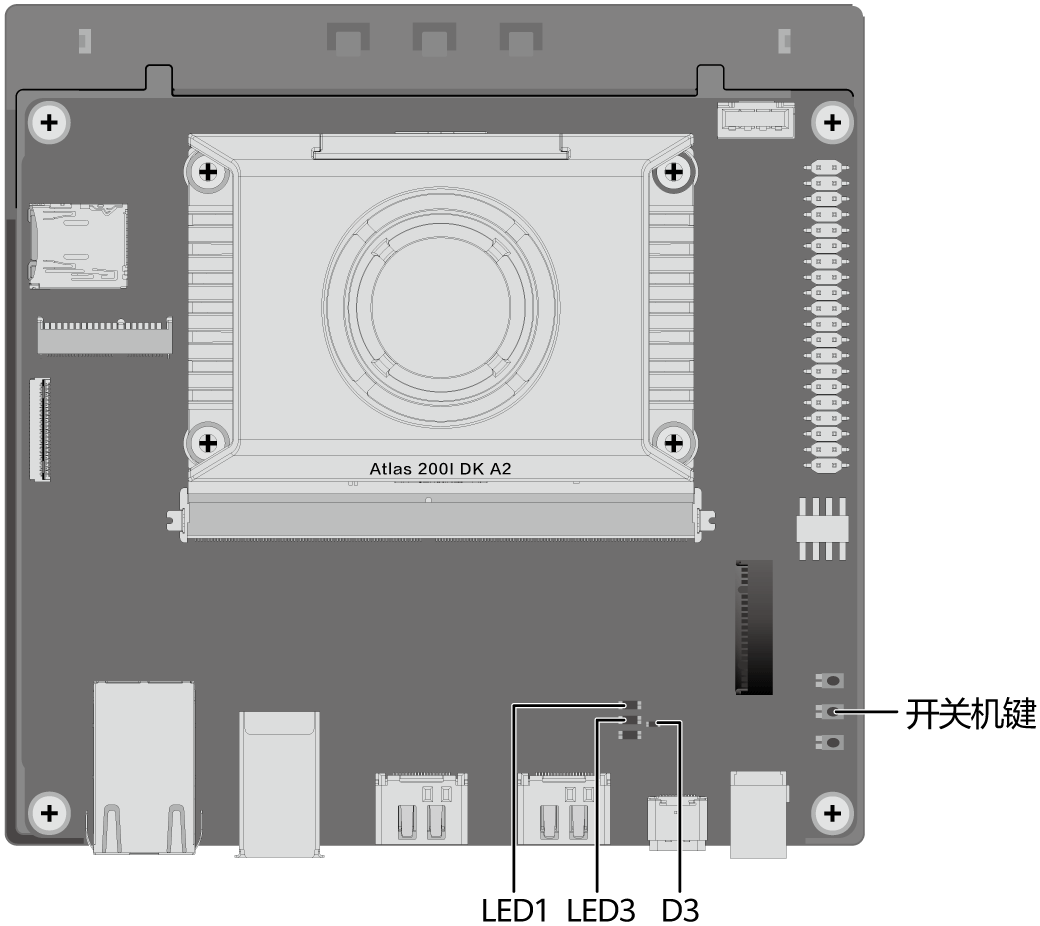

### 10.2 开机
关机状态下，短按上图中的开关机按键，开发者套件开机，LED1与LED3绿灯亮，网络正常连通，代表开发者套件已正常开机运行。

### 10.3 下电
待关机后，LED1与LED3绿灯灭，从电源接口处拔掉电源线切断外部电源，将开发者套件完全下电。

## 11. 开发板到 YOLO 端侧推理整个实验的工作流梳理

```text
1. 在本地或云服务器准备 YOLOv5s 模型
   下载 yolov5s.pt
        ↓
   使用 YOLOv5 export.py 导出 yolov5s.onnx
        ↓
   得到通用 ONNX 模型

2. 将实验文件同步到开发板
   把实验代码、yolov5s.onnx、样例图片和类别表放到开发板实验目录
        ↓
   推荐结构：
   04_YOLO_Edge_TBE_Ascend/
   ├── models/yolov5s.onnx
   ├── src/data/images/bus.jpg
   └── src/data/coco80.names

3. 在开发板上检查 CANN 与 NPU 环境
   source 开发板上的 CANN 环境脚本
        ↓
   使用 npu-smi info 确认 NPU 设备正常
        ↓
   使用 atc、python import acl 确认 ATC 和 PyACL 可用

4. 在开发板上将 ONNX 转换为 OM
   yolov5s.onnx
        ↓
   atc --soc_version=<开发板芯片型号>
        ↓
   yolov5s_<chip>.om

   注意：OM 模型与芯片强绑定，开发板是什么芯片，就必须按对应 soc_version 转换。
   例如开发板芯片是 310B4，则使用 Ascend310B4。
   
5. 在开发板上使用 PyACL 加载 OM 模型
   初始化 ACL 运行环境
        ↓
   设置 device / context / stream
        ↓
   加载 yolov5s_<chip>.om
        ↓
   准备输入输出内存
        ↓
   执行 NPU 推理
        ↓
   获取模型 raw output

6. 在开发板上完成 YOLO 后处理
   raw output
        ↓
   decode
        ↓
   score filter
        ↓
   CPU NMS
        ↓
   坐标映射
        ↓
   输出最终检测框、类别和置信度

7. 在开发板上建立 CPU 后处理基线
   记录模型推理耗时、数据搬运耗时和 CPU 后处理耗时
        ↓
   分析端侧 pipeline 中的主要瓶颈

8. 将后处理热点卸载到 NPU
   根据 CPU NMS 瓶颈设计 Ascend C / PyPTO / TileLang 自定义后处理算子
        ↓
   将自定义算子接入 PyACL 推理流程
        ↓
   对比 CPU 后处理和 NPU 后处理的延迟差异

9. 使用 MindStudio Profiling 分析性能
   采集端到端 Profiling 数据
        ↓
   分析预处理、H2D、模型推理、D2H、后处理算子耗时
        ↓
   给出端侧部署优化结论


## 12. 常见问题与处理建议

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">现象</th>
      <th style="text-align: left;">可能原因</th>
      <th style="text-align: left;">处理建议</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">制卡工具识别不到 SD 卡</td>
      <td style="text-align: left;">读卡器接触不良、SD 卡损坏、系统权限不足</td>
      <td style="text-align: left;">更换读卡器或 USB 口，以管理员身份运行工具，确认 SD 卡未写保护</td>
    </tr>
    <tr>
      <td style="text-align: left;">在线制卡失败</td>
      <td style="text-align: left;">网络不稳定、代理/杀毒软件拦截、PC 休眠</td>
      <td style="text-align: left;">使用稳定网络，关闭休眠；教学环境可改用本地制卡</td>
    </tr>
    <tr>
      <td style="text-align: left;">Windows 提示格式化 SD 卡</td>
      <td style="text-align: left;">Windows 无法识别 Linux 分区</td>
      <td style="text-align: left;">必须点“取消”，不要格式化</td>
    </tr>
    <tr>
      <td style="text-align: left;">开发板无法启动</td>
      <td style="text-align: left;">拨码错误、SD 卡未插好、镜像烧录失败、供电不足</td>
      <td style="text-align: left;">检查 SD 启动拨码、重新插卡、更换电源或重新制卡</td>
    </tr>
    <tr>
      <td style="text-align: left;">SSH 连接失败</td>
      <td style="text-align: left;">IP 不通、PC 与开发板不在同一网段、网线接错口</td>
      <td style="text-align: left;">检查 eth1/Type-C IP，使用 <code>Test-NetConnection</code> 或 <code>ping</code> 测试</td>
    </tr>
    <tr>
      <td style="text-align: left;">Jupyter Lab 打不开</td>
      <td style="text-align: left;">地址、端口、服务状态不正确</td>
      <td style="text-align: left;">先 SSH 登录开发板，确认网络通，再检查 Jupyter 服务</td>
    </tr>
    <tr>
      <td style="text-align: left;"><code>npu-smi info</code> 不可用</td>
      <td style="text-align: left;">驱动/CANN 异常或 PATH 未配置</td>
      <td style="text-align: left;">source CANN 环境脚本；仍失败则检查镜像和驱动安装</td>
    </tr>
    <tr>
      <td style="text-align: left;"><code>import acl</code> 失败</td>
      <td style="text-align: left;">当前 Python 与 PyACL 安装路径不一致</td>
      <td style="text-align: left;">使用开发板预置 Python，或修正 <code>PYTHONPATH</code> 后重启 kernel</td>
    </tr>
    <tr>
      <td style="text-align: left;">运行推理时重启 kernel</td>
      <td style="text-align: left;">内存占用过高、同时打开多个样例</td>
      <td style="text-align: left;">关闭不用的 kernel，减少视频输入，优先跑单图样例</td>
    </tr>
  </tbody>
</table>

排错顺序建议固定为：硬件连接 -> 网络登录 -> 系统命令 -> NPU 状态 -> CANN/PyACL -> 官方样例 -> 本实验代码。不要一上来就改模型脚本，否则问题会越来越混乱。


---
## 本章小结

本章完成了 Atlas 200I DK A2 开发板的基础使用教程：认识接口、使用 Ascend 一键制卡工具制作 Micro SD 系统卡、设置 SD 启动拨码、完成 本机/以太网登录、访问 Jupyter Lab，并检查 CANN、PyACL、ATC、msprof 和 NPU 状态。

下一章开始进入 YOLO 模型准备与 OM 转换。只有本章的开发板环境检查通过，后续 PyACL 推理、自定义后处理算子和 MindStudio Profiling 才能顺利开展。
